In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score, mean_squared_log_error
)
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

SEED = 67
np.random.seed(SEED)

In [2]:
df = pd.read_excel('train.xlsx')
test_df = pd.read_excel('test.xlsx')

print("Missing:")
print(df.isnull().sum()[df.isnull().sum() > 0])
display(df.head())

Missing:
video_count           577
avg_word_length       600
keyword_count         611
title_subjectivity    600
dtype: int64


,id,word_count,unique_word_rate,non_stop_rate,link_count,internal_link_count,image_count,video_count,avg_word_length,keyword_count,...,title_subjectivity,title_polarity,topic_0_score,topic_1_score,topic_2_score,topic_3_score,shares,publish_weekday,channel,is_weekend
0,0,1778,0.423299,1.0,34,33,35,0.0,4.655231,8.0,...,0.642857,0.214286,0.025001,0.025007,0.025000,0.025004,669,1,tech,0
1,1,182,0.577778,1.0,22,2,19,0.0,6.197802,7.0,...,0.150000,-0.050000,0.028744,0.465058,0.028642,0.448983,926,4,unknown,0
2,2,1115,0.440144,1.0,8,8,2,0.0,4.434978,9.0,...,0.200000,0.200000,0.022222,0.556771,0.376514,0.022270,833,5,entertainment,0
3,3,120,0.716667,1.0,4,3,1,0.0,4.591667,8.0,...,0.288889,-0.155556,0.025079,0.149858,0.025038,0.025001,1700,2,tech,0
4,4,531,0.542802,1.0,15,3,1,0.0,4.832392,4.0,...,0.500000,0.500000,0.050000,0.050000,0.799996,0.050000,3800,7,world,1


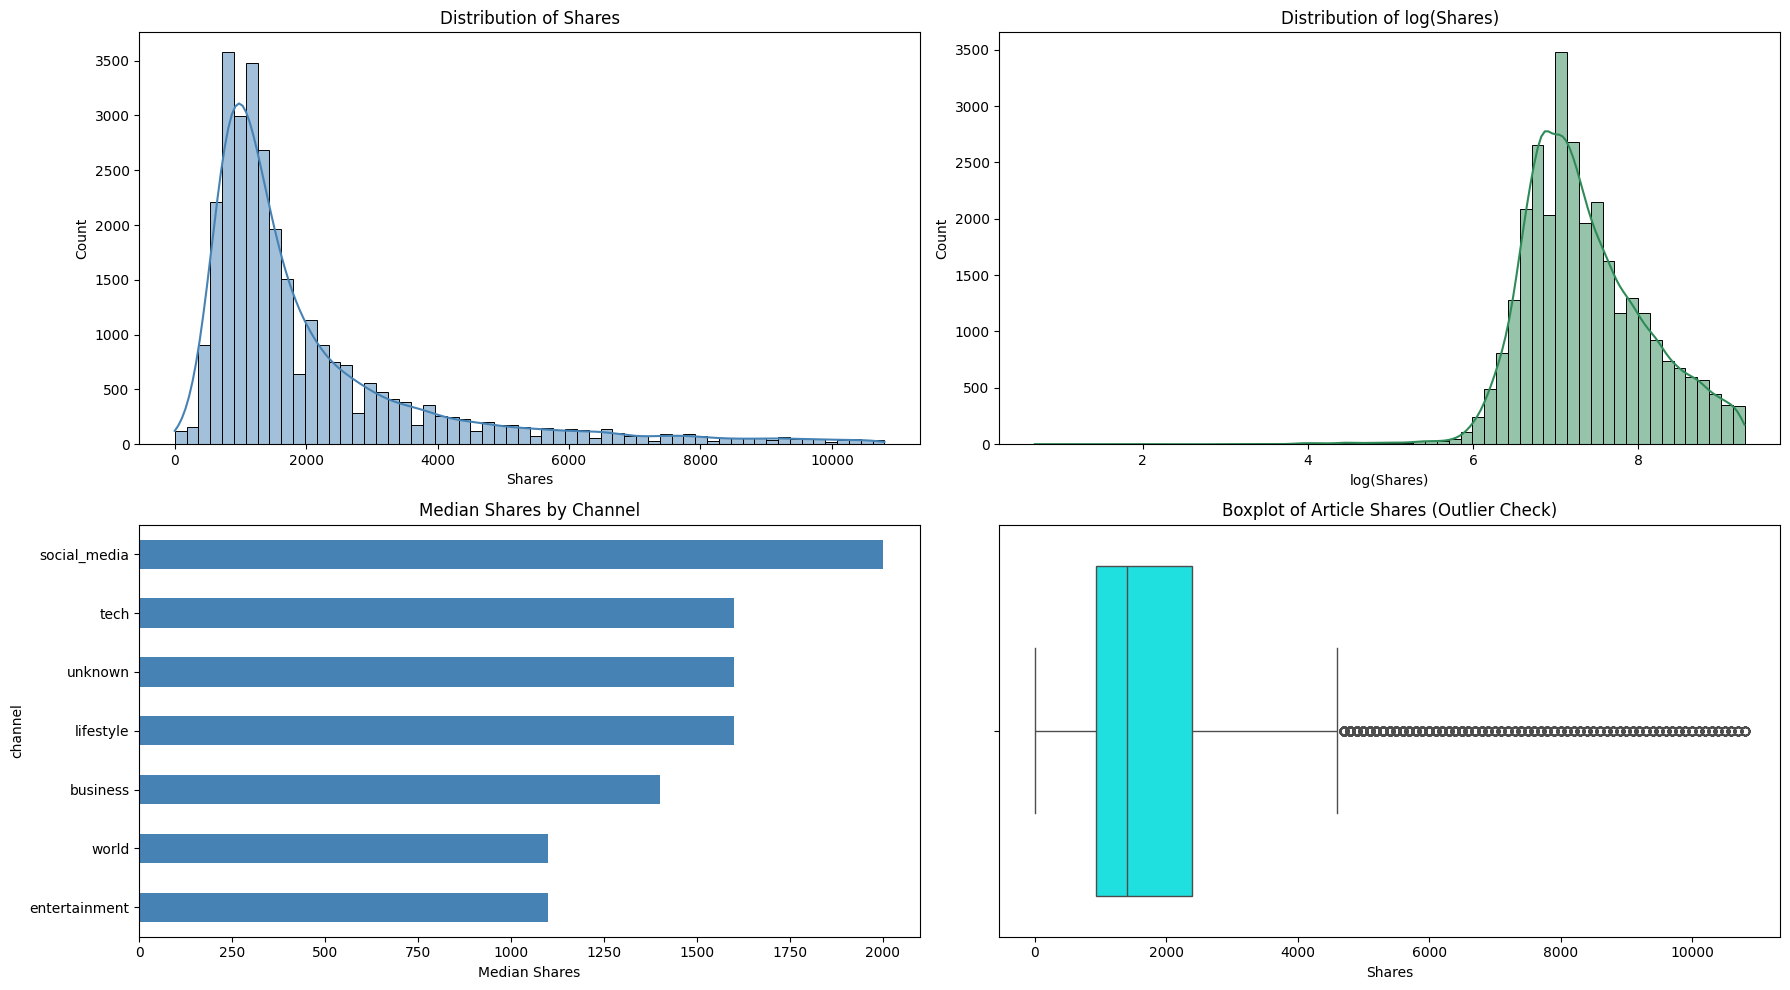

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.histplot(df['shares'], bins=60, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of Shares')
axes[0, 0].set_xlabel('Shares')

sns.histplot(np.log1p(df['shares']), bins=60, kde=True, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Distribution of log(Shares)')
axes[0, 1].set_xlabel('log(Shares)')

df.groupby('channel')['shares'].median().sort_values().plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Median Shares by Channel')
axes[1, 0].set_xlabel('Median Shares')

sns.boxplot(x=df['shares'], ax=axes[1, 1], color='cyan')
axes[1, 1].set_title('Boxplot of Article Shares (Outlier Check)')
axes[1, 1].set_xlabel('Shares')

plt.tight_layout()
plt.show()

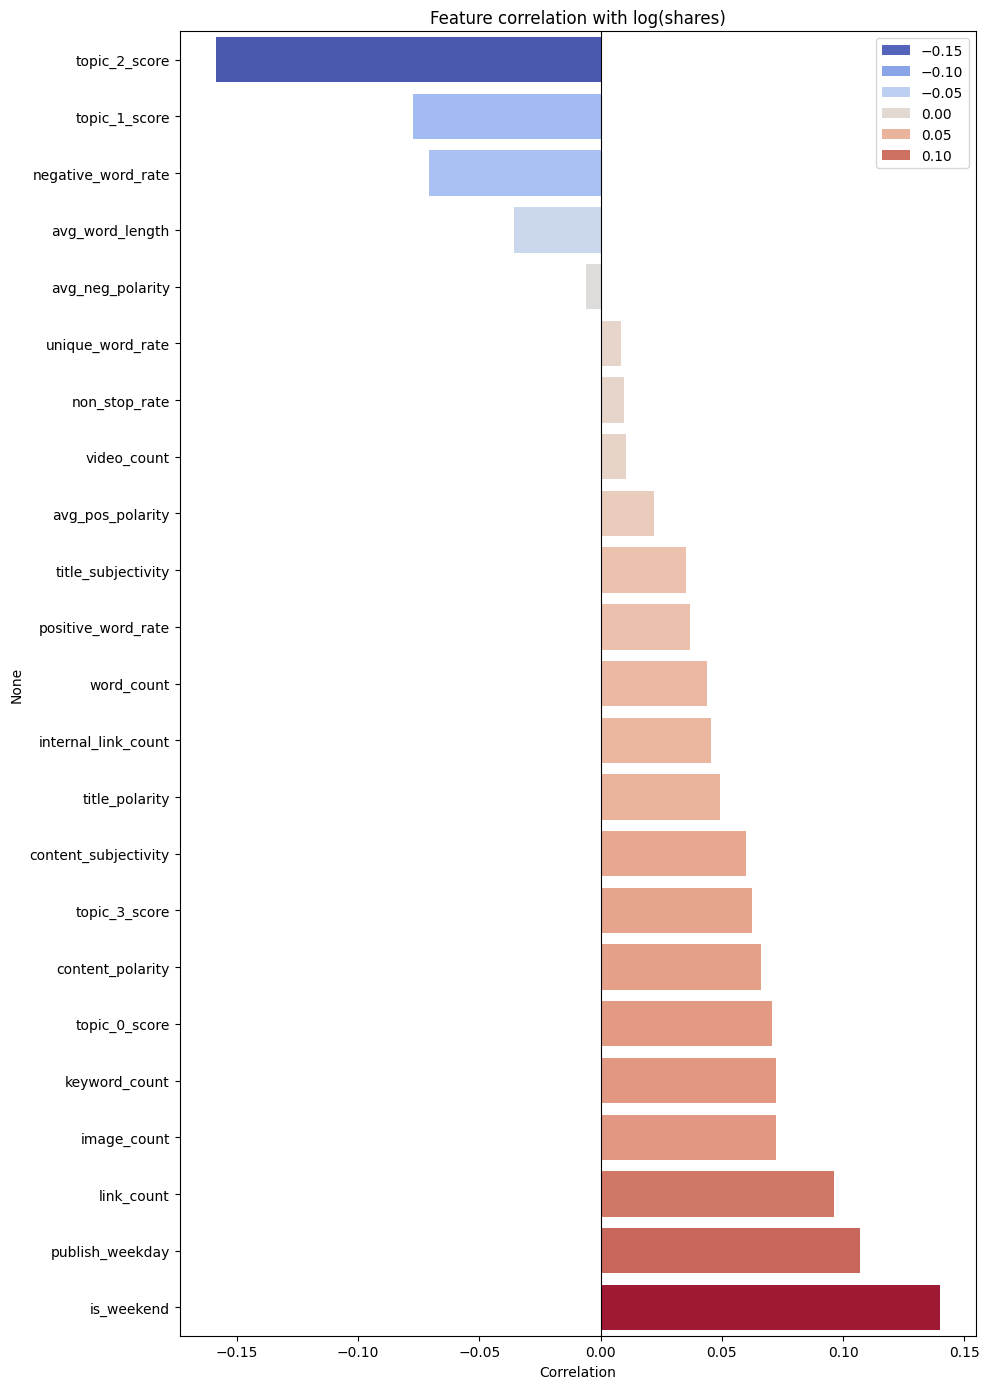

In [4]:
num_df = df.select_dtypes(include=np.number).copy()
num_df['log_shares'] = np.log1p(df['shares'])
target_corr = num_df.corr()['log_shares'].drop(['shares', 'log_shares', 'id']).sort_values()

plt.figure(figsize=(10, 14))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.values, palette='coolwarm')
plt.title('Feature correlation with log(shares)')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [5]:
TOPIC_COLS = ['topic_0_score', 'topic_1_score', 'topic_2_score', 'topic_3_score']
MISSING_COLS = ['video_count', 'avg_word_length', 'keyword_count', 'title_subjectivity']

def engineer_features(df):
    X = df.copy()

    for col in MISSING_COLS:
        if col in X.columns:
            X[f'{col}_missing'] = X[col].isna().astype(int)

    X['is_monday'] = (X['publish_weekday'] == 1).astype(int)
    X['publish_weekday_sin'] = np.sin(2 * np.pi * X['publish_weekday'] / 7)
    X['publish_weekday_cos'] = np.cos(2 * np.pi * X['publish_weekday'] / 7)

    X['image_density'] = X['image_count'] / (X['word_count'] + 1)
    X['link_density'] = X['link_count'] / (X['word_count'] + 1)
    X['internal_link_ratio'] = X['internal_link_count'] / (X['link_count'] + 1)
    X['video_density'] = X['video_count'].fillna(0) / (X['word_count'] + 1)

    for col in ['word_count', 'link_count', 'image_count', 'internal_link_count', 'video_count']:
        X[f'log_{col}'] = np.log1p(X[col].fillna(0))

    X['max_topic_score'] = X[TOPIC_COLS].max(axis=1)
    X['topic_concentration'] = X[TOPIC_COLS].max(axis=1) - X[TOPIC_COLS].mean(axis=1)
    X['topic_entropy'] = -(X[TOPIC_COLS] + 1e-9).apply(
                                   lambda r: (r * np.log(r + 1e-9)).sum(), axis=1)
    X['dominant_topic'] = X[TOPIC_COLS].values.argmax(axis=1)

    X['polarity_abs'] = X['content_polarity'].abs()
    X['sentiment_spread'] = X['avg_pos_polarity'] - X['avg_neg_polarity'].abs()
    X['subj_x_polarity'] = X['content_subjectivity'] * X['content_polarity'].abs()
    X['title_vs_content_polarity'] = X['title_polarity'] - X['content_polarity']
    X['emotion_ratio'] = X['positive_word_rate'] / (X['negative_word_rate'] + 0.01)

    X['log_word_count'] = np.log1p(X['word_count'])
    X['content_complexity'] = X['avg_word_length'].fillna(X['avg_word_length'].median()) \
                               * (1 - X['non_stop_rate'])
    X['vocabulary_richness'] = X['unique_word_rate'] * X['word_count']

    return X

In [6]:
y = df['shares'].copy()

X = df.drop(columns=['id', 'shares'])
X = engineer_features(X)                                  
X = pd.get_dummies(X, columns=['channel', 'publish_weekday'], drop_first=True)

TRAIN_COLUMNS = X.columns.tolist()                           
print(f"Total features: {len(TRAIN_COLUMNS)}")
print(f"Missing values: {X.isnull().sum().sum()}")

Total features: 61
Missing values: 2388


In [7]:
from sklearn.impute import SimpleImputer

param_dist = {
    'n_estimators':      [300, 500, 800],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [-1, 6, 8],
    'num_leaves':        [31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample':         [0.7, 0.9],
    'colsample_bytree':  [0.7, 0.9],
    'reg_alpha':         [0, 0.1],
    'reg_lambda':        [0, 0.1],
}

imp_search = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp_search.fit_transform(X), columns=X.columns)

search = RandomizedSearchCV(
    LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1),
    param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_log_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
search.fit(X_imp, np.log1p(y))
BEST_PARAMS = search.best_params_
print("Best params:", BEST_PARAMS)
print(f"Best CV RMSLE: {np.sqrt(-search.best_score_):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV RMSLE: 0.0833


In [8]:
fold_metrics = {'RMSLE': [], 'RMSE': [], 'MAE': [], 'MAPE': [], 'R2': []}
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (tr_i, val_i) in enumerate(kf.split(X)):
    X_tr  = X.iloc[tr_i].copy()
    X_val = X.iloc[val_i].copy()
    y_tr  = y.iloc[tr_i]
    y_val = y.iloc[val_i]

    imp = KNNImputer(n_neighbors=5)
    X_tr  = pd.DataFrame(imp.fit_transform(X_tr), columns=X.columns)
    X_val = pd.DataFrame(imp.transform(X_val), columns=X.columns)

    selector = LGBMRegressor(n_estimators=200, random_state=SEED, verbose=-1)
    selector.fit(X_tr, np.log1p(y_tr))
    importance = pd.Series(selector.feature_importances_, index=X.columns)
    keep = importance[importance > 0].index.tolist()

    X_tr  = X_tr[keep]
    X_val = X_val[keep]

    model = LGBMRegressor(**BEST_PARAMS, random_state=SEED, n_jobs=-1, verbose=-1)
    model.fit(
        X_tr, np.log1p(y_tr),
        eval_set=[(X_val, np.log1p(y_val))],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    preds = np.expm1(model.predict(X_val)).clip(1)

    rmsle = np.sqrt(mean_squared_log_error(y_val, preds))
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    mape = mean_absolute_percentage_error(y_val, preds)
    r2 = r2_score(y_val, preds)

    fold_metrics['RMSLE'].append(rmsle)
    fold_metrics['RMSE'].append(rmse)
    fold_metrics['MAE'].append(mae)
    fold_metrics['MAPE'].append(mape)
    fold_metrics['R2'].append(r2)

    print(f"Fold {fold+1}: RMSLE: {rmsle:.4f}  RMSE: {rmse:.1f}  R2: {r2:.4f}")

print("Average metrics:")
for metric, vals in fold_metrics.items():
    print(f"{metric:}: {np.mean(vals):.4f}")

Fold 1: RMSLE: 0.6905  RMSE: 1805.0  R2: 0.0175
Fold 2: RMSLE: 0.6826  RMSE: 1851.0  R2: 0.0163
Fold 3: RMSLE: 0.6844  RMSE: 1854.6  R2: 0.0257
Fold 4: RMSLE: 0.6931  RMSE: 1893.0  R2: 0.0090
Fold 5: RMSLE: 0.6892  RMSE: 1898.1  R2: 0.0098
Average metrics:
RMSLE: 0.6880
RMSE: 1860.3529
MAE: 1093.8115
MAPE: 0.6987
R2: 0.0156


In [9]:
imp_final = KNNImputer(n_neighbors=5)
X_all = pd.DataFrame(imp_final.fit_transform(X), columns=X.columns)

selector_final = LGBMRegressor(n_estimators=200, random_state=SEED, verbose=-1)
selector_final.fit(X_all, np.log1p(y))
importance_final = pd.Series(selector_final.feature_importances_, index=X.columns)
FINAL_COLS = importance_final[importance_final > 0].index.tolist()
X_all = X_all[FINAL_COLS]
print(f"Final feature count: {len(FINAL_COLS)}")

X_test = test_df.drop(columns=['id'])
X_test = engineer_features(X_test)                                  
X_test = pd.get_dummies(X_test, columns=['channel', 'publish_weekday'], drop_first=True)
X_test = X_test.reindex(columns=TRAIN_COLUMNS, fill_value=0)         
X_test = pd.DataFrame(imp_final.transform(X_test), columns=X.columns)
X_test = X_test[FINAL_COLS]

Final feature count: 52


In [10]:
lgbm_model = LGBMRegressor(**BEST_PARAMS, random_state=SEED, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_all, np.log1p(y))
lgbm_log_preds = lgbm_model.predict(X_test)
print("LGBM done")

LGBM done


In [11]:
xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_all, np.log1p(y))
xgb_log_preds = xgb_model.predict(X_test)
print("XGBoost done")

XGBoost done


In [12]:
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=SEED,
    verbose=0
)
cat_model.fit(X_all, np.log1p(y))
cat_log_preds = cat_model.predict(X_test)
print("CatBoost done")

CatBoost done


In [13]:
preds_log = cat_log_preds
preds = np.expm1(preds_log).clip(1)

low = np.percentile(y, 1)
high = np.percentile(y, 99)
preds = preds.clip(low, high)

In [14]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'shares': np.round(preds, 4)
})

submission.to_csv('submission.csv', index=False)
print("done")
display(submission.head(10))

done


,id,shares
0,0,1731.5730
1,1,2311.6631
2,2,1410.2369
3,3,1464.3835
4,4,1419.9633
5,5,1098.6974
6,6,1341.5771
7,7,1887.9156
8,8,1537.1378
9,9,2541.4666
